[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/MFM/blob/main/Quantlets/Ch_15/MFM_ch15_sem_partA/MFM_ch15_sem_partA.ipynb)

# MFM_ch15_sem_partA

Seminar 15, Part A: attenuation of a regression slope on a misclassified sentiment label, variance and power of paired accuracy tests, LLM label probabilities and the optimal temperature, Fleiss kappa and a Dawid-Skene step, break-even costs with delta-method standard errors.

*Modelling Financial Markets (MFM), Chapter 15: LLMs and Sentiment Analysis. Author: Daniel Traian Pele.*

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [ ]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/MFM/Chapter_15'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


In [1]:
import os
import io
import re
import sys
import json
import time
import zipfile
import subprocess
import urllib.request
for pkg, mod in (('pysentiment2', 'pysentiment2'), ('transformers', 'transformers')):
    try:
        __import__(mod)
    except ImportError:
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pkg], check=True)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Data, methods and tests

In [2]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/MFM/main/data/market/'
# copia locala a folderului data/market, daca notebook-ul ruleaza din repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')

PHRASEBANK_URL = ('https://huggingface.co/datasets/takala/financial_phrasebank/resolve/main/data/'
                  'FinancialPhraseBank-v1.0.zip')
TWITTER_URL = 'https://huggingface.co/datasets/zeroshot/twitter-financial-news-sentiment/resolve/main/'
FNSPID_URLS = ['https://huggingface.co/datasets/Zihan1004/FNSPID/resolve/main/Stock_news/All_external.csv',
               'https://huggingface.co/datasets/Zihan1004/FNSPID/resolve/main/Stock_news/nasdaq_exteral_data.csv']
LABELS = ['negative', 'neutral', 'positive']
TW_MAP = {0: 'negative', 1: 'positive', 2: 'neutral'}          # Bearish, Bullish, Neutral
AGREE = ['50Agree', '66Agree', '75Agree', 'AllAgree']

# actiuni americane cu stiri in FNSPID si preturi in data/market (Meta apare in FNSPID ca FB pana in 2022)
TICKERS = {'AAPL': 'AAPL.US', 'MSFT': 'MSFT.US', 'AMZN': 'AMZN.US', 'NVDA': 'NVDA.US', 'TSLA': 'TSLA.US',
           'GOOGL': 'GOOGL.US', 'GOOG': 'GOOGL.US', 'META': 'META.US', 'FB': 'META.US', 'JPM': 'JPM.US',
           'BAC': 'BAC.US', 'C': 'C.US', 'GS': 'GS.US', 'MS': 'MS.US', 'WFC': 'WFC.US', 'CSCO': 'CSCO.US',
           'GME': 'GME.US', 'MSTR': 'MSTR.US', 'COIN': 'COIN.US'}
LLM_SIZES = {'0.5B': 'Qwen/Qwen2.5-0.5B-Instruct', '1.5B': 'Qwen/Qwen2.5-1.5B-Instruct',
             '3B': 'Qwen/Qwen2.5-3B-Instruct', '7B': 'Qwen/Qwen2.5-7B-Instruct', '14B': 'Qwen/Qwen2.5-14B-Instruct'}
QWEN_RELEASE = '2024-09-19'          # publicarea ponderilor Qwen2.5
PROMPTS = {
    'P1': ('You classify the sentiment of financial news for investors. '
           'Answer with one word: positive, negative or neutral.', 'Headline: {x}\nSentiment:'),
    'P2': ('You are a financial analyst.', 'Is the following news good, bad or neutral for the stock price of the '
                                           'company it mentions? Answer with one word: positive, negative or '
                                           'neutral.\n\n{x}'),
    'P3': ('You are a helpful assistant.', 'Text: "{x}"\nWhat is the sentiment of this text? Reply positive, '
                                           'negative or neutral.'),
}


# =============================================================================
# DATE DE PIATA
# =============================================================================
def read_market(symbol):
    """Citeste data/market/<SIMBOL>.csv local sau din repo-ul GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname)
    src = path if os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def stock_returns(symbols, start='2009-01-01'):
    """Randamente simple zilnice (%) close-to-close pe pretul ajustat, pentru actiuni si SPY.
    Join pe preturi in zilele comune, apoi randamente."""
    px = pd.concat({s: read_market(s)['adjusted_close'] for s in symbols}, axis=1).loc[start:]
    return 100 * px.pct_change(fill_method=None)


# =============================================================================
# TEXTE ETICHETATE
# =============================================================================
def load_phrasebank():
    """Financial PhraseBank v1.0: 4,846 de propozitii din stiri financiare, etichetate de 16 adnotatori.
    Coloana 'agree': cel mai inalt prag de acord atins (50%, 66%, 75%, 100%)."""
    z = zipfile.ZipFile(io.BytesIO(urllib.request.urlopen(PHRASEBANK_URL).read()))
    sets = {}
    for lvl in AGREE:
        raw = z.read(f'FinancialPhraseBank-v1.0/Sentences_{lvl}.txt').decode('latin-1')
        sets[lvl] = [tuple(l.rsplit('@', 1)) for l in raw.splitlines() if '@' in l]
    lookup = {lvl: set(v) for lvl, v in sets.items()}
    rows = []
    for text, lab in sets['50Agree']:
        agree = max([i for i, lvl in enumerate(AGREE) if (text, lab) in lookup[lvl]] or [0])
        rows.append((text.strip(), lab.strip(), AGREE[agree]))
    d = pd.DataFrame(rows, columns=['text', 'label', 'agree'])
    return d


def load_twitter(split='valid'):
    """Twitter Financial News Sentiment: titluri de stiri financiare publicate pe Twitter, 2022; train / valid."""
    d = pd.read_csv(TWITTER_URL + f'sent_{split}.csv')
    d['label'] = d['label'].map(TW_MAP)
    return d


# =============================================================================
# DICTIONARE
# =============================================================================
def load_dictionaries():
    """Liste de cuvinte: Loughran-McDonald (negative, pozitive, incertitudine) si Harvard IV-4 (Negativ, Positiv).
    Sursa: fisierele distribuite cu pachetul pysentiment2."""
    try:
        import pysentiment2
    except ImportError:
        import subprocess, sys
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'pysentiment2'], check=True)
        import pysentiment2
    st = os.path.join(os.path.dirname(pysentiment2.__file__), 'static')
    lm = pd.read_csv(os.path.join(st, 'LM.csv'))
    lm['Word'] = lm['Word'].astype(str).str.upper()
    gi = pd.read_csv(os.path.join(st, 'HIV-4.csv'), dtype=str)
    gi['Entry'] = gi['Entry'].astype(str).str.upper().str.replace(r'#\d+$', '', regex=True)
    return {'LM_neg': set(lm.loc[lm['Negative'] > 0, 'Word']),
            'LM_pos': set(lm.loc[lm['Positive'] > 0, 'Word']),
            'LM_unc': set(lm.loc[lm['Uncertainty'] > 0, 'Word']),
            'GI_neg': set(gi.loc[gi['Negativ'].notna(), 'Entry']),
            'GI_pos': set(gi.loc[gi['Positiv'].notna(), 'Entry'])}


TOKEN = re.compile(r"[A-Za-z][A-Za-z'\-]*")


def tokens(text):
    """Cuvinte in majuscule, fara cifre si semne de punctuatie."""
    return [w.upper().strip("'-") for w in TOKEN.findall(str(text))]


def dict_counts(texts, pos, neg):
    """Numarul de cuvinte pozitive si negative din fiecare text."""
    P = np.array([sum(w in pos for w in tokens(t)) for t in texts])
    N = np.array([sum(w in neg for w in tokens(t)) for t in texts])
    return P, N


def dict_tone(texts, pos, neg):
    """Tonul: (P - N) / (P + N); 0 daca nu exista cuvinte din dictionar."""
    P, N = dict_counts(texts, pos, neg)
    return np.where(P + N > 0, (P - N) / np.maximum(P + N, 1), 0.0)


def tone_label(tone, band=0.0):
    return np.where(tone > band, 'positive', np.where(tone < -band, 'negative', 'neutral'))


def vader_compound(texts):
    """Scorul compus VADER (Hutto & Gilbert, 2014), in [-1, 1]."""
    import nltk
    try:
        from nltk.sentiment.vader import SentimentIntensityAnalyzer
        sia = SentimentIntensityAnalyzer()
    except LookupError:
        nltk.download('vader_lexicon', quiet=True)
        from nltk.sentiment.vader import SentimentIntensityAnalyzer
        sia = SentimentIntensityAnalyzer()
    return np.array([sia.polarity_scores(str(t))['compound'] for t in texts])


# =============================================================================
# MODELE DE LIMBAJ
# =============================================================================
def device():
    import torch
    if torch.cuda.is_available():
        return 'cuda'
    if torch.backends.mps.is_available():
        return 'mps'
    return 'cpu'


def finbert_probs(texts, batch=64, name='ProsusAI/finbert'):
    """Probabilitatile FinBERT (negative, neutral, positive) pentru fiecare text."""
    import torch
    from transformers import AutoTokenizer, AutoModelForSequenceClassification
    tok = AutoTokenizer.from_pretrained(name)
    m = AutoModelForSequenceClassification.from_pretrained(name).to(device()).eval()
    order = [m.config.label2id[l] for l in LABELS]
    out = []
    with torch.no_grad():
        for i in range(0, len(texts), batch):
            b = tok([str(t) for t in texts[i:i + batch]], padding=True, truncation=True, max_length=96,
                    return_tensors='pt').to(m.device)
            out.append(m(**b).logits.float().softmax(-1)[:, order].cpu().numpy())
    return np.vstack(out)


def llm_load(size):
    import torch
    from transformers import AutoTokenizer, AutoModelForCausalLM
    name = LLM_SIZES[size]
    tok = AutoTokenizer.from_pretrained(name)
    tok.padding_side = 'left'
    dev = device()
    dt = torch.float16 if dev != 'cpu' else torch.float32
    m = AutoModelForCausalLM.from_pretrained(name, dtype=dt).to(dev).eval()
    return tok, m


def llm_choice_probs(tok, m, system, user_texts, choices, batch=16):
    """Zero-shot: probabilitatile relative ale cuvintelor-raspuns (primul token al fiecaruia) la primul pas
    de generare, dupa sablonul de conversatie al modelului."""
    import torch
    ids = [tok.encode(w, add_special_tokens=False)[0] for w in choices]
    prompts = [tok.apply_chat_template([{'role': 'system', 'content': system}, {'role': 'user', 'content': u}],
                                       tokenize=False, add_generation_prompt=True) for u in user_texts]
    out = []
    with torch.no_grad():
        for i in range(0, len(prompts), batch):
            b = tok(prompts[i:i + batch], return_tensors='pt', padding=True).to(m.device)
            lg = m(**b).logits[:, -1, :][:, ids].float()
            out.append(lg.softmax(-1).cpu().numpy())
    return np.vstack(out)


def llm_sentiment(tok, m, texts, prompt='P1', batch=16):
    """Probabilitatile (negative, neutral, positive) date de un LLM zero-shot."""
    system, user = PROMPTS[prompt]
    return llm_choice_probs(tok, m, system, [user.format(x=str(t)) for t in texts], LABELS, batch)


def embed(texts, name='sentence-transformers/all-MiniLM-L6-v2', batch=128):
    """Embeddings de propozitie: media starilor ascunse (mean pooling), normalizate la lungimea 1."""
    import torch
    from transformers import AutoTokenizer, AutoModel
    tok = AutoTokenizer.from_pretrained(name)
    m = AutoModel.from_pretrained(name).to(device()).eval()
    out = []
    with torch.no_grad():
        for i in range(0, len(texts), batch):
            b = tok([str(t) for t in texts[i:i + batch]], padding=True, truncation=True, max_length=96,
                    return_tensors='pt').to(m.device)
            h = m(**b).last_hidden_state
            w = b['attention_mask'].unsqueeze(-1).float()
            e = (h * w).sum(1) / w.sum(1)
            out.append(torch.nn.functional.normalize(e, dim=1).cpu().numpy())
    return np.vstack(out)


def probs_label(P):
    """Eticheta cu probabilitatea maxima; coloanele sunt in ordinea LABELS."""
    return np.array(LABELS)[np.asarray(P).argmax(1)]


def net_score(P):
    """Scorul net de sentiment: P(pozitiv) - P(negativ), in [-1, 1]."""
    P = np.asarray(P)
    return P[:, 2] - P[:, 0]


# =============================================================================
# EVALUAREA CLASIFICARII
# =============================================================================
def confusion(y, yhat, labels=LABELS):
    return pd.crosstab(pd.Categorical(y, labels), pd.Categorical(yhat, labels), dropna=False,
                       rownames=['true'], colnames=['predicted'])


def macro_f1(y, yhat, labels=LABELS):
    y, yhat = np.asarray(y), np.asarray(yhat)
    f = []
    for l in labels:
        tp = np.sum((y == l) & (yhat == l))
        p = tp / max(np.sum(yhat == l), 1)
        r = tp / max(np.sum(y == l), 1)
        f.append(0 if p + r == 0 else 2 * p * r / (p + r))
    return float(np.mean(f))


def class_metrics(y, yhat, labels=LABELS):
    """Precizie, recall si F1 pe clase."""
    y, yhat = np.asarray(y), np.asarray(yhat)
    rows = {}
    for l in labels:
        tp = np.sum((y == l) & (yhat == l))
        p = tp / max(np.sum(yhat == l), 1)
        r = tp / max(np.sum(y == l), 1)
        rows[l] = {'precision': p, 'recall': r, 'f1': 0 if p + r == 0 else 2 * p * r / (p + r),
                   'support': int(np.sum(y == l))}
    return pd.DataFrame(rows).T


def boot_ci(y, yhat, stat, B=2000, seed=0, level=0.95):
    """Interval bootstrap (reesantionare i.i.d. a textelor) pentru o statistica a clasificarii."""
    rng = np.random.default_rng(seed)
    y, yhat = np.asarray(y), np.asarray(yhat)
    n = len(y)
    v = [stat(y[i], yhat[i]) for i in (rng.integers(0, n, n) for _ in range(B))]
    return tuple(np.quantile(v, [(1 - level) / 2, (1 + level) / 2]))


def acc(y, yhat):
    return float(np.mean(np.asarray(y) == np.asarray(yhat)))


def mcnemar(y, a, b):
    """Testul McNemar exact: compara doua clasificari pe aceleasi texte.
    n01: A greseste si B are dreptate; n10: invers."""
    y, a, b = map(np.asarray, (y, a, b))
    ca, cb = a == y, b == y
    n01, n10 = int(np.sum(~ca & cb)), int(np.sum(ca & ~cb))
    p = stats.binomtest(min(n01, n10), n01 + n10, 0.5).pvalue if n01 + n10 > 0 else 1.0
    return n01, n10, float(p)


def diff_ci(y, a, b, B=2000, seed=0):
    """Interval bootstrap pentru diferenta de acuratete acc(B) - acc(A), pe aceleasi texte."""
    rng = np.random.default_rng(seed)
    y, a, b = map(np.asarray, (y, a, b))
    n = len(y)
    d = [np.mean(b[i] == y[i]) - np.mean(a[i] == y[i]) for i in (rng.integers(0, n, n) for _ in range(B))]
    return tuple(np.quantile(d, [0.025, 0.975]))


# =============================================================================
# STIRI DATATE SI SEMNALE
# =============================================================================
def load_fnspid(paths=None, tickers=TICKERS):
    """Titlurile FNSPID (ambele fisiere: surse externe si Nasdaq) pentru actiunile din TICKERS:
    data (UTC), titlu, simbol. Titlurile repetate (acelasi titlu, aceeasi actiune, aceeasi zi) apar o singura data."""
    out = []
    for src in (paths or FNSPID_URLS):
        for ch in pd.read_csv(src, usecols=['Date', 'Article_title', 'Stock_symbol'], chunksize=500_000, dtype=str,
                              on_bad_lines='skip'):
            out.append(ch[ch['Stock_symbol'].isin(tickers)])
    d = pd.concat(out).dropna()
    d['ts'] = pd.to_datetime(d['Date'], utc=True, errors='coerce')
    d = d.dropna(subset=['ts'])
    d['ticker'] = d['Stock_symbol'].map(lambda s: TICKERS[s].replace('.US', ''))
    d['title'] = d['Article_title'].str.strip()
    d = d.assign(dd=d['ts'].dt.date).drop_duplicates(['ticker', 'title', 'dd'])
    return d[['ts', 'ticker', 'title']].reset_index(drop=True)


def assign_trading_day(ts, days):
    """FNSPID da doar data publicarii (ora este 00:00 UTC pentru aproape toate titlurile): titlul datat d
    este atribuit primei zile de tranzactionare >= d. Ora din zi nu se cunoaste, deci stirea poate aparea
    si dupa inchiderea zilei d."""
    d0 = ts.dt.tz_convert('UTC').dt.tz_localize(None).dt.normalize()
    days = pd.DatetimeIndex(days).sort_values()
    pos = days.searchsorted(d0.values)
    ok = pos < len(days)
    out = pd.Series(pd.NaT, index=ts.index)
    out[ok] = days[pos[ok]]
    return out


def daily_panel(S, rets):
    """S: scoruri medii pe (zi, actiune), indexate (day, ticker). Adauga randamentul in exces fata de SPY
    in ziua stirii (r0), in urmatoarele doua zile (r1, r2) si in zilele -5..+5 (studiul de eveniment:
    rm5..rm1, r0, r1, r2, rp3..rp5). Cu date fara ora, r1 poate contine inca reactia la stire; primul randament
    sigur de tranzactionat este r2 (de la inchiderea zilei urmatoare)."""
    ex = rets.drop(columns='SPY').sub(rets['SPY'], axis=0)
    P = S.copy()
    for k in range(-5, 6):
        name = {0: 'r0', 1: 'r1', 2: 'r2'}.get(k, f'rp{k}' if k > 0 else f'rm{-k}')
        sh = ex.shift(-k).stack()
        sh.index.names = ['day', 'ticker']
        P = P.join(sh.rename(name), how='left')
    return P.dropna(subset=['r0', 'r1', 'r2'])


def cluster_ols(y, x, groups):
    """OLS y = a + b x cu erori standard obisnuite si grupate pe zile (Petersen, 2009)."""
    X = np.column_stack([np.ones(len(x)), x])
    y = np.asarray(y, float)
    XtX = np.linalg.inv(X.T @ X)
    b = XtX @ X.T @ y
    e = y - X @ b
    n, k = X.shape
    V_ols = XtX * (e @ e) / (n - k)
    idx_g = pd.Series(np.arange(n)).groupby(np.asarray(groups)).apply(list)
    meat = sum(np.outer(X[i].T @ e[i], X[i].T @ e[i]) for i in idx_g)
    G = len(idx_g)
    V_cl = XtX @ meat @ XtX * G / (G - 1) * (n - 1) / (n - k)
    return {'b': b[1], 'a': b[0], 'se_ols': np.sqrt(V_ols[1, 1]), 'se_cl': np.sqrt(V_cl[1, 1]),
            't_ols': b[1] / np.sqrt(V_ols[1, 1]), 't_cl': b[1] / np.sqrt(V_cl[1, 1]),
            'r2': 1 - (e @ e) / np.sum((y - y.mean()) ** 2), 'n': n, 'G': G}


def nw_t(x, lags=None):
    """Media si statistica t cu varianta Newey-West (HAC)."""
    x = np.asarray(x, float)
    x = x[~np.isnan(x)]
    n = len(x)
    L = lags if lags is not None else int(np.floor(4 * (n / 100) ** (2 / 9)))
    u = x - x.mean()
    v = u @ u / n
    for l in range(1, L + 1):
        v += 2 * (1 - l / (L + 1)) * (u[l:] @ u[:-l]) / n
    return x.mean(), x.mean() / np.sqrt(v / n)


def block_boot_mean(x, B=2000, block=10, seed=0):
    """Interval bootstrap pe blocuri mobile pentru media unei serii zilnice."""
    rng = np.random.default_rng(seed)
    x = np.asarray(x, float)
    n = len(x)
    nb = int(np.ceil(n / block))
    v = []
    for _ in range(B):
        st = rng.integers(0, n - block + 1, nb)
        v.append(np.concatenate([x[s:s + block] for s in st])[:n].mean())
    return tuple(np.quantile(v, [0.025, 0.975]))


def signal_portfolio(P, col, days, cost_bp=0.0, band=0.0, ret='r2'):
    """Strategia zilnica: pentru fiecare actiune cu stiri (|scor| > band) luam pozitia sign(scor), acoperita cu SPY,
    ponderi egale; castigul este randamentul in exces din coloana ret (implicit r2: pozitia se deschide la
    inchiderea zilei de dupa stire, cand stirea este sigur publica). Zilele fara pozitii au randament 0.
    Costul: cost_bp puncte de baza pe fiecare tranzactie (actiune si SPY, la intrare si la iesire: 4 x cost)."""
    q = P[P[col].abs() > band]
    lag = {'r0': 0, 'r1': 1, 'r2': 2}[ret]
    pos_day = pd.DatetimeIndex(days)
    idx = pos_day.get_indexer(q.index.get_level_values('day'))
    ok = (idx >= 0) & (idx + lag < len(pos_day))
    q = q[ok]
    earn_day = pos_day[idx[ok] + lag]
    x = pd.Series(np.sign(q[col].values) * q[ret].values, index=earn_day)
    grp = x.groupby(level=0)
    R = pd.DataFrame({'gross': grp.mean(), 'k': grp.size()}).reindex(pos_day).fillna(0.0)
    R['net'] = R['gross'] - np.where(R['k'] > 0, 4 * cost_bp / 100, 0.0)
    return R


def sharpe(x, ppy=252):
    x = np.asarray(x, float)
    return float(np.sqrt(ppy) * x.mean() / x.std(ddof=1))

## Style and helpers

In [3]:
# Stil standard MFM: transparent + ENG + legenda jos
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'none'
plt.rcParams['savefig.facecolor'] = 'none'
plt.rcParams['savefig.transparent'] = True
plt.rcParams['axes.grid'] = False
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
plt.rcParams['font.size'] = 9
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['axes.titlesize'] = 10
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.linewidth'] = 0.6
plt.rcParams['lines.linewidth'] = 1.1
plt.rcParams['legend.facecolor'] = 'none'
plt.rcParams['legend.framealpha'] = 0
plt.rcParams['legend.fontsize'] = 8

# Culori brand
MainBlue = '#1A3A6E'
IDAred = '#CD0000'
Forest = '#2E7D32'
Amber = '#B5853F'
Orange = '#E67E22'
Purple = '#8E44AD'
Crimson = '#DC3545'
Teal = '#17A2B8'
Magenta = '#D63384'
Brown = '#795548'
Gray = '#7F7F7F'          # doar linii de referinta
LightGray = '#DADADA'     # doar benzi

LAB_COL = {'negative': IDAred, 'neutral': Amber, 'positive': Forest}
METHODS = ['GI', 'VADER', 'LM', 'TF-IDF + LR', 'MiniLM + LR', 'FinBERT', 'Qwen 0.5B', 'Qwen 1.5B', 'Qwen 3B',
           'Qwen 7B', 'Qwen 14B']
M_COL = {'GI': Brown, 'VADER': Amber, 'LM': Orange, 'TF-IDF + LR': Teal, 'MiniLM + LR': Magenta,
         'FinBERT': MainBlue, 'Qwen 0.5B': '#F4A6A6', 'Qwen 1.5B': '#E86A6A', 'Qwen 3B': Crimson,
         'Qwen 7B': IDAred, 'Qwen 14B': '#7A0000'}
SIZES_B = {'0.5B': 0.5, '1.5B': 1.5, '3B': 3.0, '7B': 7.0, '14B': 14.0}
SCORE_LBL = {'lm': 'Loughran-McDonald tone', 'finbert': 'FinBERT', 'qwen': 'Qwen2.5-7B'}
SCORE_COL = {'lm': Orange, 'finbert': MainBlue, 'qwen': IDAred}
EVENT_COLS = ['rm5', 'rm4', 'rm3', 'rm2', 'rm1', 'r0', 'r1', 'r2', 'rp3', 'rp4', 'rp5']
PERIODS = (('2010', '2015'), ('2016', '2019'), ('2020', '2021'), ('2022', '2023'))


RES = {}
FC_RAW = 'https://raw.githubusercontent.com/danpele/MFM/main/Quantlets/Ch_15/'
FC_DIR = next((d for d in ('.', '..', 'Quantlets/Ch_15', '../Quantlets/Ch_15', '../../Quantlets/Ch_15')
               if os.path.exists(os.path.join(d, 'ch15_twitter_scores.csv'))), None)


def save_fig(name):
    """Salveaza figura ca PDF si PNG transparent, in folderul curent."""
    plt.savefig(f'{name}.pdf', bbox_inches='tight', transparent=True)
    plt.savefig(f'{name}.png', bbox_inches='tight', transparent=True, dpi=180)
    plt.show()
    plt.close()
    print(f"   saved {name}")


def load_csv(name, **kw):
    """Tabelul de scoruri ch15_*.csv (produs de run_scores), local sau din repository."""
    path = os.path.join(FC_DIR, name) if FC_DIR else FC_RAW + name
    return pd.read_csv(path, **kw)


def legend_outside_bottom(ax, ncol=2, y=-0.22, **kw):
    """Plaseaza legenda in afara graficului, jos-centru."""
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False, **kw)


def fig_legend_bottom(fig, handles, labels, ncol=3, y=0.0):
    """O singura legenda pentru toata figura, sub panouri."""
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def predictions(d):
    """Eticheta prezisa de fiecare metoda (coloanele ch15_*_scores.csv)."""
    v = d['vader'].values
    out = {'GI': tone_label(d['GI_tone'].values), 'LM': tone_label(d['LM_tone'].values),
           'VADER': np.where(v >= 0.05, 'positive', np.where(v <= -0.05, 'negative', 'neutral')),
           'TF-IDF + LR': probs_label(d[[f'tfidf_{l}' for l in LABELS]].values),
           'MiniLM + LR': probs_label(d[[f'emb_{l}' for l in LABELS]].values),
           'FinBERT': probs_label(d[[f'finbert_{l}' for l in LABELS]].values)}
    for s in SIZES_B:
        out[f'Qwen {s}'] = probs_label(d[[f'qwen{s}_{l}' for l in LABELS]].values)
    return out


def jsonable(o):
    if isinstance(o, dict):
        return {str(k): jsonable(v) for k, v in o.items() if not isinstance(v, pd.DataFrame)}
    if isinstance(o, (list, tuple)):
        return [jsonable(v) for v in o]
    if isinstance(o, (np.floating, np.integer)):
        return o.item()
    return o

LAB_COL = {'negative': '#CD0000', 'neutral': '#B5853F', 'positive': '#2E7D32'}
METHODS = ['GI', 'VADER', 'LM', 'TF-IDF + LR', 'MiniLM + LR', 'FinBERT', 'Qwen 0.5B', 'Qwen 1.5B', 'Qwen 3B', 'Qwen 7B', 'Qwen 14B']
M_COL = {'GI': '#795548', 'VADER': '#B5853F', 'LM': '#E67E22', 'TF-IDF + LR': '#17A2B8', 'MiniLM + LR': '#D63384', 'FinBERT': '#1A3A6E', 'Qwen 0.5B': '#F4A6A6', 'Qwen 1.5B': '#E86A6A', 'Qwen 3B': '#DC3545', 'Qwen 7B': '#CD0000', 'Qwen 14B': '#7A0000'}
SIZES_B = {'0.5B': 0.5, '1.5B': 1.5, '3B': 3.0, '7B': 7.0, '14B': 14.0}
SCORE_LBL = {'lm': 'Loughran-McDonald tone', 'finbert': 'FinBERT', 'qwen': 'Qwen2.5-7B'}
SCORE_COL = {'lm': '#E67E22', 'finbert': '#1A3A6E', 'qwen': '#CD0000'}
EVENT_COLS = ['rm5', 'rm4', 'rm3', 'rm2', 'rm1', 'r0', 'r1', 'r2', 'rp3', 'rp4', 'rp5']
PERIODS = (('2010', '2015'), ('2016', '2019'), ('2020', '2021'), ('2022', '2023'))

## Sentiment scores

In [4]:
HERE = '.'
SEED = 15
MONTHS = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']


def tick(msg, t0):
    print(f'   {msg}: {time.time() - t0:.0f}s', flush=True)


def dict_cols(d, texts, D):
    for k in ('LM', 'GI'):
        P, N = dict_counts(texts, D[k + '_pos'], D[k + '_neg'])
        d[f'{k}_pos'], d[f'{k}_neg'] = P, N
        d[f'{k}_tone'] = np.where(P + N > 0, (P - N) / np.maximum(P + N, 1), 0.0)
    d['vader'] = vader_compound(texts)


def texts_block():
    t0 = time.time()
    pb, tw, tr = load_phrasebank(), load_twitter('valid'), load_twitter('train')
    D = load_dictionaries()
    out = {'pb': pb[['label', 'agree']].copy(), 'tw': tw[['label']].copy()}
    src = {'pb': pb['text'].tolist(), 'tw': tw['text'].tolist()}
    for k in out:
        dict_cols(out[k], src[k], D)
    tick('dictionaries', t0)
    for k in out:
        P = finbert_probs(src[k])
        for j, l in enumerate(LABELS):
            out[k][f'finbert_{l}'] = P[:, j]
    tick('FinBERT', t0)
    for size in LLM_SIZES:
        tok, m = llm_load(size)
        for k in out:
            prompts = ['P1', 'P2', 'P3'] if (k == 'tw' and size in ('1.5B', '7B', '14B')) else ['P1']
            for pr in prompts:
                t1 = time.time()
                P = llm_sentiment(tok, m, src[k], pr)
                tag = f'qwen{size}' + ('' if pr == 'P1' else f'_{pr}')
                for j, l in enumerate(LABELS):
                    out[k][f'{tag}_{l}'] = P[:, j]
                out[k].attrs[f'time_{tag}'] = (time.time() - t1) / len(src[k])
        del m
        try:
            import torch
            torch.mps.empty_cache()
        except Exception:
            pass
        tick(f'Qwen {size}', t0)
    # embeddings + regresie logistica, invatate pe setul de antrenare Twitter
    from sklearn.linear_model import LogisticRegression
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.decomposition import PCA
    Etr, Etw, Epb = embed(tr['text'].tolist()), embed(src['tw']), embed(src['pb'])
    clf = LogisticRegression(C=4.0, max_iter=3000).fit(Etr, tr['label'])
    for k, E in (('tw', Etw), ('pb', Epb)):
        P = clf.predict_proba(E)[:, [list(clf.classes_).index(l) for l in LABELS]]
        for j, l in enumerate(LABELS):
            out[k][f'emb_{l}'] = P[:, j]
    tf = TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True).fit(tr['text'])
    clf2 = LogisticRegression(C=8.0, max_iter=3000).fit(tf.transform(tr['text']), tr['label'])
    for k in out:
        P = clf2.predict_proba(tf.transform(src[k]))[:, [list(clf2.classes_).index(l) for l in LABELS]]
        for j, l in enumerate(LABELS):
            out[k][f'tfidf_{l}'] = P[:, j]
    pc = PCA(2, random_state=SEED).fit(Etr)
    xy = pc.transform(Etw)
    out['tw']['pc1'], out['tw']['pc2'] = xy[:, 0], xy[:, 1]
    tick('embeddings', t0)
    # curba de invatare: cate etichete sunt necesare?
    rng = np.random.default_rng(SEED)
    rows = []
    for n in (100, 200, 400, 800, 1600, 3200, 6400, len(tr)):
        for rep in range(10 if n < len(tr) else 1):
            idx = rng.choice(len(tr), n, replace=False) if n < len(tr) else np.arange(len(tr))
            y = tr['label'].values[idx]
            if len(set(y)) < 3:
                continue
            a = LogisticRegression(C=4.0, max_iter=3000).fit(Etr[idx], y).predict(Etw)
            tfn = TfidfVectorizer(ngram_range=(1, 2), min_df=1, sublinear_tf=True).fit(tr['text'].values[idx])
            b = LogisticRegression(C=8.0, max_iter=3000).fit(tfn.transform(tr['text'].values[idx]), y).predict(
                tfn.transform(src['tw']))
            rows.append({'n': n, 'rep': rep, 'emb_acc': acc(tw['label'], a), 'emb_f1': macro_f1(tw['label'], a),
                         'tfidf_acc': acc(tw['label'], b), 'tfidf_f1': macro_f1(tw['label'], b)})
    pd.DataFrame(rows).to_csv(os.path.join(HERE, 'ch15_learning_curve.csv'), index=False)
    for k, name in (('pb', 'ch15_phrasebank_scores.csv'), ('tw', 'ch15_twitter_scores.csv')):
        out[k].round(6).to_csv(os.path.join(HERE, name), index_label='id')
    times = {**out['tw'].attrs}
    pd.Series(times).to_csv(os.path.join(HERE, 'ch15_llm_time.csv'), header=['sec_per_text'])
    tick('texts done', t0)


def memory_block(sizes=('1.5B', '7B', '14B')):
    """Directia lunara a S&P 500 (2000-2026) si directia zilnica a Apple, intrebate fara niciun context."""
    t0 = time.time()
    px = read_market('GSPC.INDX')['close']
    mon = px.resample('ME').last()
    mret = 100 * mon.pct_change().dropna().loc['2000-01':'2026-08']
    aapl = read_market('AAPL.US')['adjusted_close']
    dret = 100 * aapl.pct_change().dropna()
    rng = np.random.default_rng(SEED)
    pre = dret.loc['2010-01-01':'2023-12-31']
    post = dret.loc['2024-10-01':]
    days = pd.concat([pre.iloc[np.sort(rng.choice(len(pre), 500, replace=False))], post])
    dm = pd.DataFrame({'ret': mret})
    dd = pd.DataFrame({'ret': days})
    sys_m = 'You are a financial historian. Answer with one word: rise or fall.'
    q_m = [f'Did the S&P 500 index rise or fall during {MONTHS[d.month - 1]} {d.year}?' for d in dm.index]
    sys_d = 'You are a financial historian. Answer with one word: higher or lower.'
    q_d = [f'Did Apple (AAPL) stock close higher or lower on {d.strftime("%A")}, {MONTHS[d.month - 1]} {d.day}, '
           f'{d.year} than on the previous trading day?' for d in dd.index]
    for size in sizes:
        tok, m = llm_load(size)
        dm[f'qwen{size}'] = llm_choice_probs(tok, m, sys_m, q_m, ['rise', 'fall'])[:, 0]
        dd[f'qwen{size}'] = llm_choice_probs(tok, m, sys_d, q_d, ['higher', 'lower'])[:, 0]
        del m
        tick(f'memory {size}', t0)
    dm.round(6).to_csv(os.path.join(HERE, 'ch15_memory_monthly.csv'), index_label='month')
    dd.round(6).to_csv(os.path.join(HERE, 'ch15_memory_daily.csv'), index_label='date')


def news_block(paths=None, llm='7B', batch=64):
    """Scoruri pentru fiecare titlu, apoi medii pe (zi de tranzactionare, actiune)."""
    t0 = time.time()
    news = load_fnspid(paths)
    tick(f'FNSPID {len(news)} headlines', t0)
    rets = stock_returns(sorted(set(TICKERS.values())) + ['SPY.US'], start='2009-01-01')
    rets.columns = [c.replace('.US', '') for c in rets.columns]
    news['day'] = assign_trading_day(news['ts'], rets.index)
    news = news.dropna(subset=['day'])
    news = news[news['day'] >= '2009-06-01']
    D = load_dictionaries()
    P, N = dict_counts(news['title'].tolist(), D['LM_pos'], D['LM_neg'])
    news['lm'] = np.where(P + N > 0, (P - N) / np.maximum(P + N, 1), 0.0)
    news['lm_hit'] = (P + N > 0).astype(int)
    F = finbert_probs(news['title'].tolist(), batch=256)
    news['finbert'] = net_score(F)
    news['finbert_lab'] = F.argmax(1) - 1
    tick('FinBERT', t0)
    tok, m = llm_load(llm)
    Q = llm_sentiment(tok, m, news['title'].tolist(), 'P1', batch=batch)
    news['qwen'] = net_score(Q)
    tick(f'Qwen {llm}', t0)
    grp = news.groupby(['day', 'ticker'])
    daily = grp[['finbert', 'lm', 'qwen']].mean()
    daily['n'] = grp.size()
    daily['lm_hit'] = grp['lm_hit'].mean()
    daily.round(6).to_csv(os.path.join(HERE, 'ch15_news_daily.csv'))
    by_year = news.groupby([news['day'].dt.year, 'ticker']).size().unstack(fill_value=0)
    by_year.to_csv(os.path.join(HERE, 'ch15_news_counts.csv'))
    hour = news['ts'].dt.tz_convert('UTC').dt.hour.value_counts().reindex(range(24), fill_value=0)
    exact = ((news['ts'].dt.hour == 0) & (news['ts'].dt.minute == 0) & (news['ts'].dt.second == 0)).mean()
    pd.DataFrame({'n': hour, 'share_midnight': exact}).to_csv(os.path.join(HERE, 'ch15_news_hours.csv'))
    # scorurile titlurilor individuale (fara text) pentru comparatia metodelor
    news[['day', 'ticker', 'finbert', 'finbert_lab', 'lm', 'lm_hit', 'qwen']].round(5).to_csv(
        os.path.join(HERE, 'ch15_news_headlines.csv.gz'), index=False, compression='gzip')
    tick('news done', t0)

In [5]:
# True: refacerea tuturor scorurilor (descarcarea modelelor FinBERT, MiniLM si Qwen2.5 0.5B-14B si a titlurilor
# FNSPID; ore de calcul fara GPU); False: tabelele ch15_*.csv publicate in folderul Capitolului 15.
RECOMPUTE = False
if RECOMPUTE:
    texts_block()
    memory_block()
    news_block()
    FC_DIR = '.'

## Analysis

In [6]:
def dict_example(text, D):
    w = tokens(text)
    out = {}
    for k in ('LM', 'GI'):
        pos = [x for x in w if x in D[k + '_pos']]
        neg = [x for x in w if x in D[k + '_neg']]
        P, N = len(pos), len(neg)
        out[k] = {'pos': pos, 'neg': neg, 'P': P, 'N': N, 'tone': (P - N) / (P + N) if P + N else 0.0}
    out['n_words'] = len(w)
    return out


def part_a():
    """A1-A2: tonul dupa doua dictionare; A3-A4: metrici din matricea de confuzie; A5-A6: probabilitati si
    clasa majoritara; A7-A8: costul la care strategia nu mai castiga nimic."""
    pb = load_phrasebank()
    D = load_dictionaries()
    # propozitii reale din PhraseBank (acord 100%) in care cele doua dictionare dau semne diferite
    allag = pb[pb['agree'] == 'AllAgree'].copy()
    allag['len'] = allag['text'].str.len()
    lm = dict_tone(allag['text'], D['LM_pos'], D['LM_neg'])
    gi = dict_tone(allag['text'], D['GI_pos'], D['GI_neg'])
    c1 = allag[(allag['label'] == 'positive') & (lm > 0) & (gi < 0)].sort_values('len')
    c2 = allag[(allag['label'] == 'neutral') & (lm == 0) & (gi < 0)].sort_values('len')
    for key, text in (('A1', c1['text'].iloc[0]), ('A2', c2['text'].iloc[0])):
        r = dict_example(text, D)
        r['label'] = pb.loc[pb['text'] == text, 'label'].iloc[0]
        r['text'] = text
        S[key] = r
    tw = load_csv('ch15_twitter_scores.csv')
    pr = predictions(tw)
    for key, m in (('A3', 'FinBERT'), ('A4', 'LM')):
        cm = confusion(tw['label'], pr[m])
        cmx = class_metrics(tw['label'], pr[m])
        S[key] = {'cm': cm.values.tolist(), 'acc': acc(tw['label'], pr[m]), 'f1': macro_f1(tw['label'], pr[m]),
                  'metrics': cmx.to_dict('index')}
    # A5: probabilitatile Qwen2.5-7B pentru un titlu; temperatura
    i = int(np.argmin(np.abs(tw['qwen7B_negative'] - 0.62)))
    p = tw.loc[i, ['qwen7B_negative', 'qwen7B_neutral', 'qwen7B_positive']].values.astype(float)
    logit = np.log(np.maximum(p, 1e-12))
    logit = logit - logit.max()
    T = 2.0
    pT = np.exp(logit / T) / np.exp(logit / T).sum()
    S['A5'] = {'id': i, 'label': tw.loc[i, 'label'], 'p': p.tolist(), 'logit': logit.tolist(), 'T': T,
               'pT': pT.tolist(), 'net': float(p[2] - p[0])}
    n = tw['label'].value_counts()
    S['A6'] = {'n': n.to_dict(), 'N': int(n.sum()), 'acc_neutral': float(n['neutral'] / n.sum()),
               'f1_neutral_class': float(2 * (n['neutral'] / n.sum()) / (1 + n['neutral'] / n.sum())),
               'macro_f1': macro_f1(tw['label'], np.full(len(tw), 'neutral'))}


def b_pairs(a, b, data='tw'):
    d = load_csv('ch15_twitter_scores.csv' if data == 'tw' else 'ch15_phrasebank_scores.csv')
    y = d['label'].values
    pr = predictions(d)
    n01, n10, p = mcnemar(y, pr[a], pr[b])
    lo, hi = diff_ci(y, pr[a], pr[b])
    return {'acc_a': acc(y, pr[a]), 'acc_b': acc(y, pr[b]), 'diff': acc(y, pr[b]) - acc(y, pr[a]),
            'lo': lo, 'hi': hi, 'n01': n01, 'n10': n10, 'p': p,
            'ci_a': boot_ci(y, pr[a], acc), 'ci_b': boot_ci(y, pr[b], acc)}


def part_a_inference(R):
    """A1-A8 (derivari): atenuarea prin clasificare gresita (Aigner, 1973), varianta si puterea testului McNemar,
    kappa Fleiss si un pas E Dawid-Skene pe un tabel mic, conditia de ordinul intai pentru temperatura,
    eroarea standard a costului de echilibru (metoda delta)."""
    from scipy import stats as st
    out = {}
    # A1-A2: variabila "stire negativa" (rand/coloana 0 din matricea de confuzie Twitter)
    for key in ('A3', 'A4'):
        cm = np.array(S[key]['cm'], float)
        n = cm.sum()
        pi = cm[0].sum() / n
        p = cm[:, 0].sum() / n
        a1 = (cm[0, 1] + cm[0, 2]) / cm[0].sum()
        a0 = (cm[1, 0] + cm[2, 0]) / (cm[1].sum() + cm[2].sum())
        lam = pi * (1 - pi) * (1 - a0 - a1) / (p * (1 - p))
        out['att_' + key] = {'n': n, 'pi': pi, 'p': p, 'a0': a0, 'a1': a1, 'lam': lam, 'inv': 1 / lam,
                             'n_tp': cm[0, 0], 'n_neg': cm[0].sum(), 'n_predneg': cm[:, 0].sum(),
                             'n_fp': cm[1, 0] + cm[2, 0], 'n_nonneg': cm[1].sum() + cm[2].sum()}
    # A3-A4: diferenta de acuratete pe perechi, varianta multinomiala, McNemar exact, puterea
    for key in ('B1', 'B2'):
        b = S[key]
        n = int(np.array(S['A3']['cm']).sum())       # titlurile din setul de validare Twitter
        n01, n10 = b['n01'], b['n10']
        d = (n01 - n10) / n
        q = (n01 + n10) / n
        se = np.sqrt((q - d ** 2) / n)
        pz = 2 * st.norm.sf(abs(d) / se)
        pex = 2 * st.binom.cdf(min(n01, n10), n01 + n10, 0.5)
        zc = st.norm.ppf(0.975)
        power = st.norm.cdf(abs(d) * np.sqrt(n) / np.sqrt(q - d ** 2) - zc)
        n80 = (zc + st.norm.ppf(0.8)) ** 2 * (q - d ** 2) / d ** 2
        out['mc_' + key] = {'n': n, 'n01': n01, 'n10': n10, 'd': d, 'q': q, 'se': se, 'lo': d - zc * se, 'hi': d + zc * se,
                            'p_z': pz, 'p_exact': min(1.0, pex), 'power': power, 'n80': n80}
    # A6: kappa Fleiss si un pas E Dawid-Skene pe un tabel ilustrativ (6 propozitii x 5 evaluatori)
    V = np.array([[5, 0, 0], [0, 5, 0], [0, 1, 4], [1, 3, 1], [2, 3, 0], [0, 2, 3]], float)
    m = V.sum(1)[0]
    Pi = (V * (V - 1)).sum(1) / (m * (m - 1))
    pj = V.sum(0) / V.sum()
    Pbar, Pe = Pi.mean(), (pj ** 2).sum()
    kappa = (Pbar - Pe) / (1 - Pe)
    acc_r = 0.8
    Pi_mat = np.full((3, 3), (1 - acc_r) / 2) + np.eye(3) * (acc_r - (1 - acc_r) / 2)
    like = np.array([[np.prod(Pi_mat[j] ** v) for j in range(3)] for v in V])
    post = like / like.sum(1, keepdims=True)
    maj = V / V.sum(1, keepdims=True)
    out['fleiss'] = {'votes': V.tolist(), 'Pi': Pi.tolist(), 'pj': pj.tolist(), 'Pbar': Pbar, 'Pe': Pe, 'kappa': kappa,
                     'acc_r': acc_r, 'post': post.tolist(), 'share': maj.tolist()}
    # A5(d): temperatura optima pentru Qwen2.5-7B (conditia de ordinul intai), pe jumatatea de validare
    tw = load_csv('ch15_twitter_scores.csv')
    y = tw['label'].map({'negative': 0, 'neutral': 1, 'positive': 2}).values
    P = tw[['qwen7B_negative', 'qwen7B_neutral', 'qwen7B_positive']].values.astype(float)
    Z = np.log(np.clip(P / P.sum(1, keepdims=True), 1e-12, 1))
    idx = np.random.default_rng(15).permutation(len(y))[:len(y) // 2]
    Zv, yv = Z[idx], y[idx]

    def foc(T):
        L = Zv / T
        L = L - L.max(1, keepdims=True)
        E = np.exp(L)
        Pt = E / E.sum(1, keepdims=True)
        return float(np.mean(Zv[np.arange(len(yv)), yv]) - np.mean((Pt * Zv).sum(1)))
    from scipy.optimize import brentq
    T_star = brentq(foc, 0.5, 50)
    out['temp'] = {'T': T_star, 'foc_1': foc(1.0), 'foc_T': foc(T_star)}
    # A7-A8: costul de echilibru si eroarea lui standard (metoda delta, varianta Newey-West a mediei)
    for c in ('finbert', 'qwen'):
        x = R['news']['strat'][c]
        mu, t, a = x['mean_bp'], x['t'], x['active']
        se_mu = mu / t
        cstar = mu / (4 * a)
        se_c = se_mu / (4 * a)
        sigma = np.sqrt(252) * mu / x['sr']
        out['cost_' + c] = {'mu': mu, 't': t, 'a': a, 'se_mu': se_mu, 'c': cstar, 'se_c': se_c,
                            'lo': cstar - 1.96 * se_c, 'hi': cstar + 1.96 * se_c, 'sigma': sigma,
                            'sr': x['sr'], 'sr_net5': np.sqrt(252) * (mu - 4 * a * 5) / sigma, 'sr_net': x['sr_net']}
    S['AI'] = out
    return out


def news_panel():
    daily = load_csv('ch15_news_daily.csv', parse_dates=['day']).set_index(['day', 'ticker'])
    syms = sorted(set(TICKERS.values()))
    rets = stock_returns(syms + ['SPY.US'], start='2009-01-01')
    rets.columns = [c.replace('.US', '') for c in rets.columns]
    rets = rets.loc[:'2023-12-31']
    P = daily_panel(daily, rets)
    for c in SCORE_LBL:
        P[f'z_{c}'] = (P[c] - P[c].mean()) / P[c].std()
    return P, rets


def event_groups(x):
    """Grupurile studiului de eveniment: tercila cea mai negativa si cea mai pozitiva a scorului zilnic. Daca cele
    doua praguri coincid (tonul LM este exact 0 in aproape jumatate din zilele-actiune), grupurile disjuncte sunt
    scor < prag si scor > prag, iar zilele egale cu pragul sunt excluse."""
    q1, q2 = x.quantile([1 / 3, 2 / 3])
    if q1 >= q2:
        return x < q1, x > q2
    return x <= q1, x >= q2


def eval_news(P, rets):
    cnt = load_csv('ch15_news_counts.csv', index_col=0)
    hl = load_csv('ch15_news_headlines.csv.gz', usecols=['finbert', 'lm', 'lm_hit', 'qwen', 'finbert_lab'])
    R = {'n_headlines': int(cnt.values.sum()), 'n_tickers': int((cnt.sum() > 0).sum()),
         'n_obs': len(P), 'n_days': int(P.index.get_level_values('day').nunique()),
         'first': str(P.index.get_level_values('day').min().date()),
         'last': str(P.index.get_level_values('day').max().date()),
         'per_year': cnt.sum(1).to_dict(), 'per_ticker': cnt.sum().sort_values(ascending=False).to_dict(),
         'mean_n': float(P['n'].mean()), 'lm_hit': float(hl['lm_hit'].mean()),
         'fb_share': (hl['finbert_lab'].value_counts(normalize=True).sort_index()).tolist(),
         'corr': hl[['lm', 'finbert', 'qwen']].corr().round(3).to_dict(),
         'corr_daily': P[['lm', 'finbert', 'qwen']].corr().round(3).to_dict()}
    R['reg'] = {}
    groups = P.index.get_level_values('day')
    for c in SCORE_LBL:
        for y in ('r0', 'r1', 'r2'):
            R['reg'][f'{c}|{y}'] = {k: float(v) for k, v in cluster_ols(P[y].values, P[f'z_{c}'].values,
                                                                           groups).items()}
    # studiul de eveniment: tercilele scorului FinBERT
    cols = EVENT_COLS
    R['event'] = {}
    for c in ('finbert', 'qwen', 'lm'):
        neg, pos = event_groups(P[c])
        ev = {}
        for grp, sel in (('neg', neg), ('pos', pos)):
            X = P.loc[sel, cols].groupby(level='day').mean()
            car = X.fillna(0).cumsum(axis=1)
            ev[grp] = {'car': car.mean().tolist(), 'se': (car.std() / np.sqrt(len(car))).tolist(), 'n_days': len(X),
                       'n': int(sel.sum())}
        R['event'][c] = ev
    # strategia
    days = rets.index[(rets.index >= P.index.get_level_values('day').min())]
    R['strat'] = {}
    for c in SCORE_LBL:
        St = signal_portfolio(P, c, days, cost_bp=5, ret='r2')
        S1 = signal_portfolio(P, c, days, ret='r1')
        m1, t1 = nw_t(S1['gross'])
        mu, t = nw_t(St['gross'])
        lo, hi = block_boot_mean(St['gross'].values)
        mun, tn = nw_t(St['net'])
        active = St['k'] > 0
        R['strat'][c] = {'mean_bp': 1e2 * mu, 't': t, 'lo_bp': 1e2 * lo, 'hi_bp': 1e2 * hi,
                         'sr': sharpe(St['gross']), 'sr_net': sharpe(St['net']), 't_net': tn,
                         'mean_net_bp': 1e2 * mun, 'active': float(active.mean()),
                         'mean_active_bp': 1e2 * St.loc[active, 'gross'].mean(),
                         'breakeven_bp': 1e2 * St.loc[active, 'gross'].mean() / 4,
                         'r1_mean_bp': 1e2 * m1, 'r1_t': t1, 'r1_sr': sharpe(S1['gross']),
                         'years': {}}
        for a, b in PERIODS:
            x = St.loc[a:b, 'gross']
            m_, t_ = nw_t(x)
            R['strat'][c]['years'][f'{a}-{b}'] = {'mean_bp': 1e2 * m_, 't': t_}
        R['strat'][c]['cum'] = St[['gross', 'net']]
    RES['news'] = R
    return P


def fig_a1_attenuation(key='A3', name='ch15_sem_a1_attenuation', label='FinBERT', col=None, reps=2000, seed=15):
    """A1/A2: distributia pantei OLS pe variabila adevarata s* si pe variabila prezisa s_hat, simulata cu ratele de
    clasificare gresita din matricea de confuzie Twitter; beta = 1, zgomot N(0, 1), n = numarul de titluri."""
    x = S['AI']['att_' + key]
    n, pi, a0, a1, lam = int(x['n']), x['pi'], x['a0'], x['a1'], x['lam']
    rng = np.random.default_rng(seed)
    bt, bh = np.empty(reps), np.empty(reps)
    for k in range(reps):
        s = rng.random(n) < pi
        u = rng.random(n)
        sh = np.where(s, u >= a1, u < a0)
        r = s + rng.standard_normal(n)
        bt[k] = np.cov(r, s)[0, 1] / np.var(s, ddof=1)
        bh[k] = np.cov(r, sh)[0, 1] / np.var(sh, ddof=1)
    fig, ax = plt.subplots(figsize=(6.4, 2.8))
    bins = np.linspace(min(bh.min(), bt.min()), max(bh.max(), bt.max()), 60)
    ax.hist(bt, bins=bins, color=MainBlue, alpha=0.75, label='Slope on the true dummy $s^*$')
    ax.hist(bh, bins=bins, color=col or Forest, alpha=0.75, label=f'Slope on the {label} dummy $\\hat s$')
    ax.axvline(1.0, color=MainBlue, lw=1.2, ls='--', label=r'True $\beta = 1$')
    ax.axvline(lam, color=IDAred, lw=1.2, ls='--', label=rf'$\beta\lambda = {lam:.3f}$')
    ax.set_xlabel(f'OLS slope, {reps:,} simulated samples of {n:,} headlines')
    ax.set_ylabel('Number of samples')
    legend_outside_bottom(ax, ncol=2, y=-0.24)
    save_fig(name)
    return {'mean_true': float(bt.mean()), 'mean_hat': float(bh.mean()), 'sd_hat': float(bh.std(ddof=1))}


def fig_power(keys=('mc_B1',), labels=('LM vs FinBERT',), name='ch15_sem_a3_power'):
    """A3/A4: puterea testului pe perechi in functie de numarul de titluri, cu d si q estimate pe Twitter."""
    from scipy import stats as st
    zc = st.norm.ppf(0.975)
    nn = np.logspace(2, 4.6, 200)
    fig, ax = plt.subplots(figsize=(6.4, 2.8))
    for key, lab, col in zip(keys, labels, (MainBlue, IDAred)):
        x = S['AI'][key]
        d, q, n0 = abs(x['d']), x['q'], x['n']
        pw = st.norm.cdf(d * np.sqrt(nn) / np.sqrt(q - d ** 2) - zc)
        ax.plot(nn, pw, color=col, lw=1.6, label=f'{lab}: $d$ = {100 * x["d"]:+.1f} pp')
        ax.plot([n0], [x['power']], 'o', color=col, ms=5)
        ax.axvline(x['n80'], color=col, lw=0.9, ls=':', label=f'{lab}: $n_{{80}}$ = {x["n80"]:,.0f}')
    ax.axhline(0.8, color=Gray, lw=0.7, ls='--')
    ax.axvline(S['AI'][keys[0]]['n'], color=Gray, lw=0.7)
    ax.set_xscale('log')
    ax.set_ylim(0, 1.02)
    ax.set_xlabel('Number of headlines $n$ (log scale); solid grey line: the validation set, dots: its power')
    ax.set_ylabel('Power at 5%')
    legend_outside_bottom(ax, ncol=2, y=-0.26)
    save_fig(name)


def fig_cost(key='cost_finbert', label='FinBERT', name='ch15_sem_a7_cost'):
    """A7/A8: randamentul net zilnic mediu in functie de costul pe tranzactie, cu banda +-1.96 SE (a fix)."""
    x = S['AI'][key]
    c = np.linspace(0, 6, 121)
    net = x['mu'] - 4 * x['a'] * c
    fig, ax = plt.subplots(figsize=(6.4, 2.8))
    ax.fill_between(c, net - 1.96 * x['se_mu'], net + 1.96 * x['se_mu'], color=LightGray, alpha=0.7,
                    label=r'$\pm 1.96$ SE of the mean')
    ax.plot(c, net, color=MainBlue, lw=1.6, label=f'{label} strategy: mean net return per day')
    ax.axhline(0, color=Gray, lw=0.7)
    ax.axvline(x['c'], color=IDAred, lw=1.2, ls='--', label=f'Break-even cost $c^*$ = {x["c"]:.2f} bp')
    ax.axvspan(max(x['lo'], 0), x['hi'], color=IDAred, alpha=0.12, label='95% CI of $c^*$')
    ax.axvline(5, color=Amber, lw=1.2, label='Realistic cost, 5 bp per trade')
    ax.set_xlabel('Cost per trade $c$ (bp); four trades on each day with positions')
    ax.set_ylabel('Mean net return (bp per day)')
    legend_outside_bottom(ax, ncol=3, y=-0.26)
    save_fig(name)

## Run

{
 "A1": {
  "LM": {
   "pos": [
    "IMPROVED"
   ],
   "neg": [],
   "P": 1,
   "N": 0,
   "tone": 1.0
  },
  "GI": {
   "pos": [],
   "neg": [
    "SPITE",
    "DECREASE"
   ],
   "P": 0,
   "N": 2,
   "tone": -1.0
  },
  "n_words": 15,
  "label": "positive",
  "text": "Uponor improved its performance in spite of the decrease in residential construction in the US ."
 },
 "A2": {
  "LM": {
   "pos": [],
   "neg": [],
   "P": 0,
   "N": 0,
   "tone": 0.0
  },
  "GI": {
   "pos": [],
   "neg": [
    "INFLATION"
   ],
   "P": 0,
   "N": 1,
   "tone": -1.0
  },
  "n_words": 6,
  "label": "neutral",
  "text": "The ECB can mainly target inflation ."
 },
 "A3": {
  "cm": [
   [
    264,
    71,
    12
   ],
   [
    213,
    1184,
    169
   ],
   [
    58,
    133,
    284
   ]
  ],
  "acc": 0.7252931323283082,
  "f1": 0.6681732301000801,
  "metrics": {
   "negative": {
    "precision": 0.4934579439252336,
    "recall": 0.760806916426513,
    "f1": 0.598639455782313,
    "support": 347.0
 

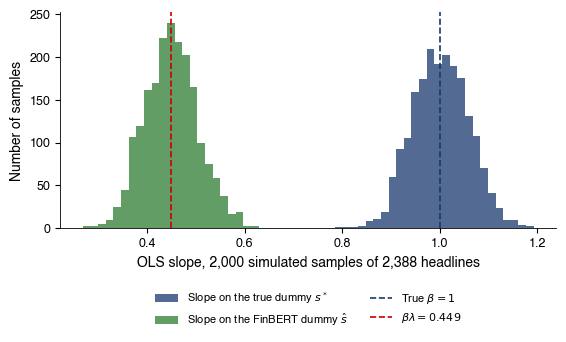

   saved ch15_sem_a1_attenuation


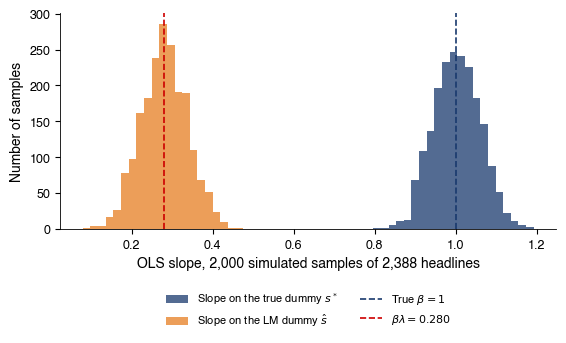

   saved ch15_sem_a2_attenuation


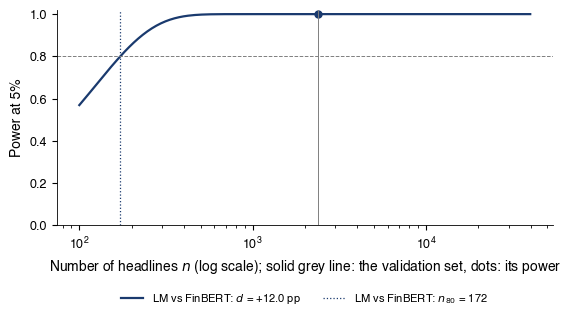

   saved ch15_sem_a3_power


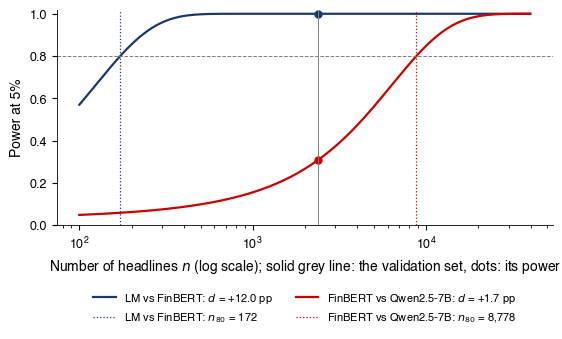

   saved ch15_sem_a4_power


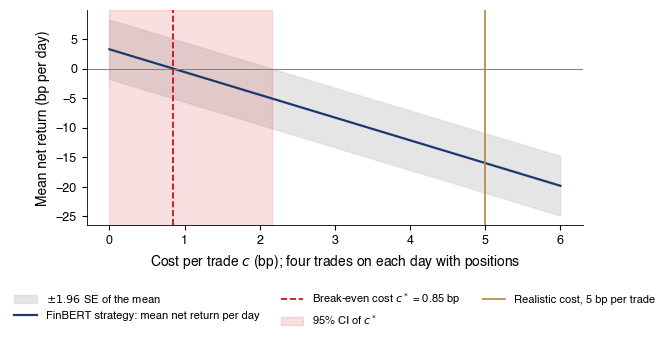

   saved ch15_sem_a7_cost


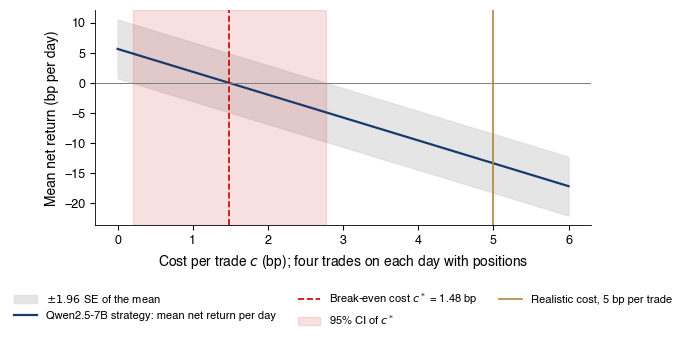

   saved ch15_sem_a8_cost


In [7]:
S = {}
part_a()
S['B1'] = b_pairs('LM', 'FinBERT')
S['B2'] = b_pairs('FinBERT', 'Qwen 7B')
P, rets = news_panel()
eval_news(P, rets)
part_a_inference(RES)
print(json.dumps(jsonable(S), indent=1, default=float))
fig_a1_attenuation()
fig_a1_attenuation('A4', 'ch15_sem_a2_attenuation', 'LM', Orange)
fig_power()
fig_power(('mc_B1', 'mc_B2'), ('LM vs FinBERT', 'FinBERT vs Qwen2.5-7B'), 'ch15_sem_a4_power')
fig_cost()
fig_cost('cost_qwen', 'Qwen2.5-7B', 'ch15_sem_a8_cost')

![ch15_sem_a1_attenuation](./ch15_sem_a1_attenuation.png)

Output: `ch15_sem_a1_attenuation.pdf`

![ch15_sem_a2_attenuation](./ch15_sem_a2_attenuation.png)

Output: `ch15_sem_a2_attenuation.pdf`

![ch15_sem_a3_power](./ch15_sem_a3_power.png)

Output: `ch15_sem_a3_power.pdf`

![ch15_sem_a4_power](./ch15_sem_a4_power.png)

Output: `ch15_sem_a4_power.pdf`

![ch15_sem_a7_cost](./ch15_sem_a7_cost.png)

Output: `ch15_sem_a7_cost.pdf`

![ch15_sem_a8_cost](./ch15_sem_a8_cost.png)

Output: `ch15_sem_a8_cost.pdf`